## Finetuned Model Post-Processing

**Heads**

Default: your custom head (for the dataset you gave `--train-file` earlier)

pt_head: pre-training/replay head, samples drawn from the replay .xyz file, a snapshot of the original foundation model's training set

In [72]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# ==== USER INPUT HERE ====
RUN_IDS = [733909, 734253, 734395]

RUNS = {}
for run in RUN_IDS:
    RUNS[run] = {
        "out_file": f"mace_{run}.out",
        "err_file": f"mace_{run}.err",
        "train_script": f"train_{run}.sbatch",
        "finetune_df": None,
        "replay_df": None,
        "training_params": {}
    }

In [22]:
# load job.out generated by training run into df

def make_df(run):
    pattern = re.compile(
        r"(?:Epoch (\d+)|(Initial)): head: (\S+), "
        r"loss=([\d.]+), "
        r"RMSE_E_per_atom=\s*([\d.]+) meV, "
        r"RMSE_F=\s*([\d.]+) meV / A, "
        r"RMSE_stress=\s*(None|[\d.]+) meV / A\^3"
    )
    with open(f"../logs/{run['out_file']}", "r") as f:
        log_out = f.read()

    matches = pattern.findall(log_out)

    rows = [
        (epoch_num if epoch_num else "-1", *rest)
        for epoch_num, _initial, *rest in matches
    ]

    df = pd.DataFrame(
        rows,
        columns=["epoch", "head", "loss", "RMSE_E_per_atom", "RMSE_F", "RMSE_stress"]
    )
    for col in ["epoch", "loss", "RMSE_E_per_atom", "RMSE_F"]:
        df[col] = pd.to_numeric(df[col])
    df['RMSE_stress'] = pd.to_numeric(df['RMSE_stress'], errors="coerce")

    # separate out dfs for each model head
    run["finetune_df"] = df[df["head"] == "Default"].copy()
    run["replay_df"] = df[df["head"] == "pt_head"].copy()

In [18]:
# get training params

def get_params(run):
    with open(f"../logs/{run['train_script']}", "r") as f:
        text = f.read()

    patterns = {
        "lr": r"--lr (\d+\.\d+)",
        "swa_lr": r"--swa_lr (\d+\.\d+)",
        "e_weight": r"--energy_weight (\d+\.\d+)",
        "f_weight": r"--forces_weight (\d+\.\d+)",
        "swa_e_weight": r"--swa_energy_weight (\d+\.\d+)",
        "swa_f_weight": r"--swa_forces_weight (\d+\.\d+)",
    }

    run['training_params'] = {
        key: float(match.group(1)) if (match := re.search(pattern, text)) else None
        for key, pattern in patterns.items()
    }

In [23]:
for run in RUNS.values():
    make_df(run)
    get_params(run)

**Graph Error**

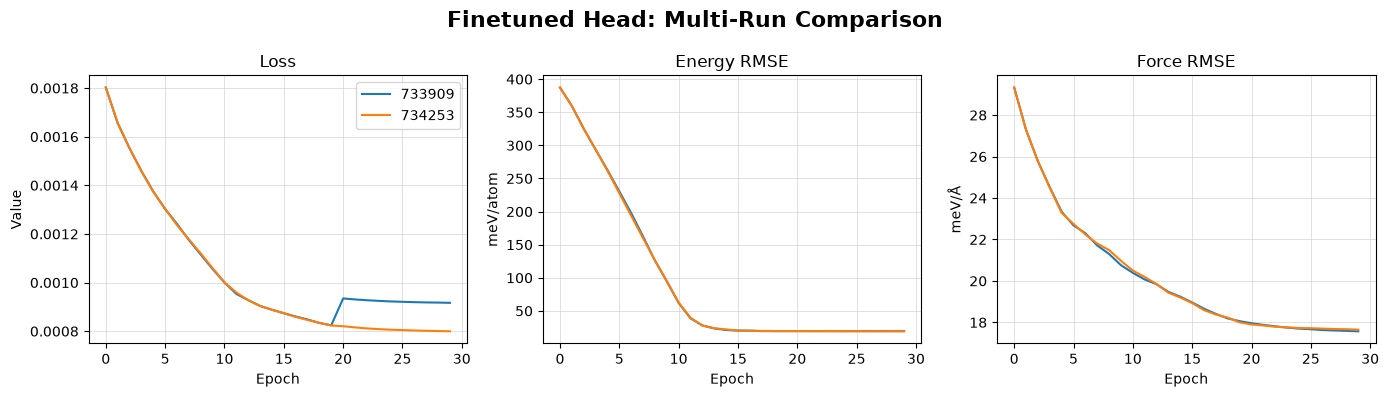

In [ ]:
# graph runs side-by-side (cols: loss, RMSE_E, RMSE_F)

fig, axs = plt.subplots(1, 3, figsize=(14, 4), dpi=100, sharex=True, sharey=False)
fig.suptitle("Finetuned Head: Multi-Run Comparison", fontsize=16, fontweight='semibold')

metrics = [
    ("loss", "Loss", "Loss"),
    ("RMSE_E_per_atom", "Energy RMSE", "meV/atom"),
    ("RMSE_F", "Force RMSE", "meV/Å"),
]

for ax, (col, title, ylabel) in zip(axs, metrics):
    for run in RUN_IDS:
        df = RUNS[run]["finetune_df"]

        ax.plot(df["epoch"].iloc[1:], df[col].iloc[1:], label=str(run))

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(color='lightgrey', linewidth=0.5)

axs[0].set_ylabel("Value")
axs[0].legend()

plt.tight_layout()
plt.show()

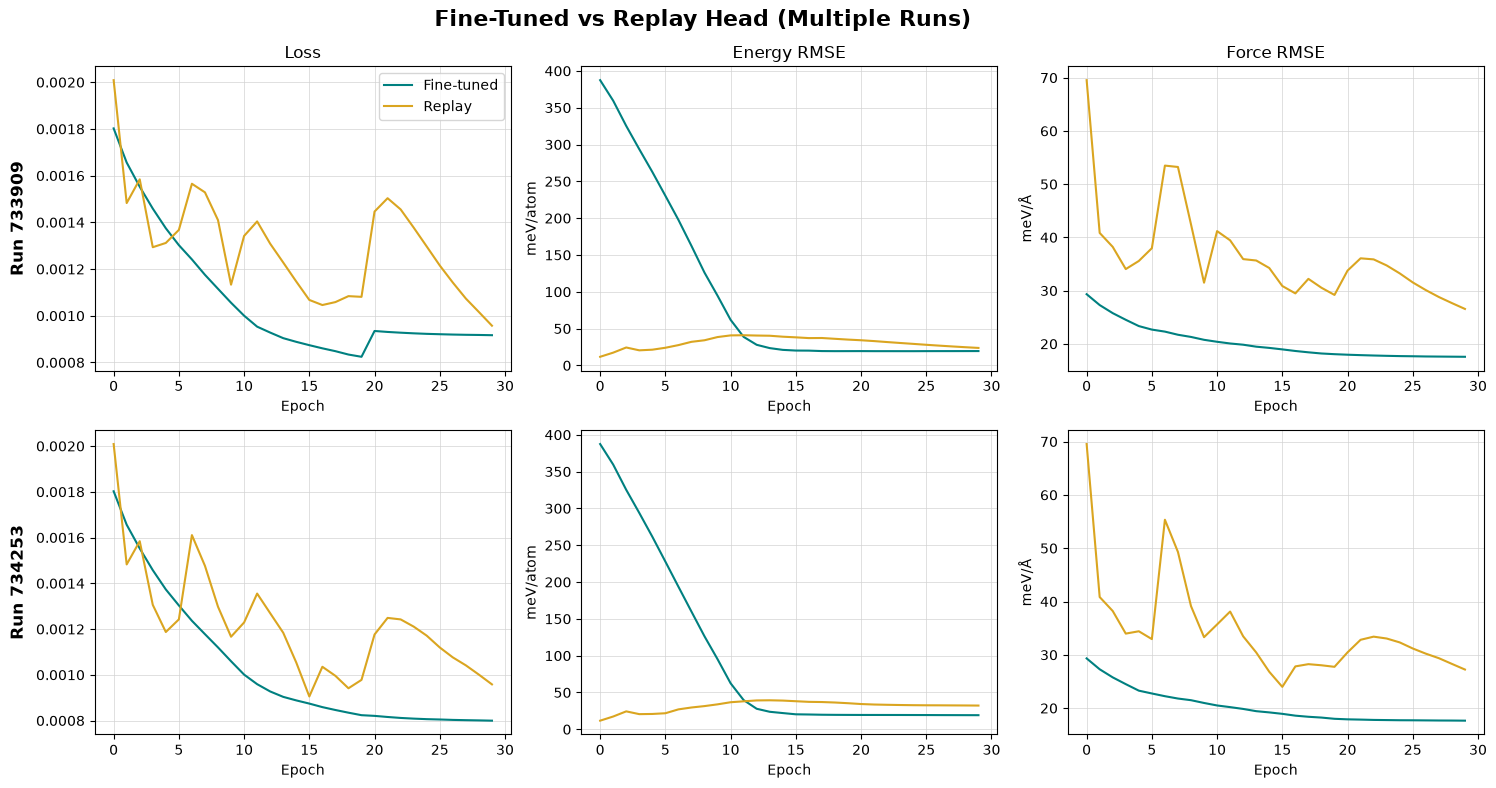

In [90]:
fig, axs = plt.subplots(nrows=len(RUN_IDS), ncols=3, figsize=(16, 4 * len(RUN_IDS)), dpi=100, sharex=True, sharey=False)

fig.suptitle("Fine-Tuned vs Replay Head (Multiple Runs)", fontsize=16, fontweight="semibold")

metrics = [
    ("loss", "Loss", "Loss"),
    ("RMSE_E_per_atom", "Energy RMSE", "meV/atom"),
    ("RMSE_F", "Force RMSE", "meV/Å"),
]

if len(RUN_IDS) == 1:
    axs = axs[np.newaxis, :]

for i, run in enumerate(RUN_IDS):

    df_ft = RUNS[run]["finetune_df"]
    df_rp = RUNS[run]["replay_df"]

    for j, (ax, (col, title, ylabel)) in enumerate(zip(axs[i], metrics)):
        ax.plot(df_ft["epoch"].iloc[1:], df_ft[col].iloc[1:], label="Fine-tuned", color="teal")
        ax.plot(df_rp["epoch"].iloc[1:], df_rp[col].iloc[1:], label="Replay", color="goldenrod")

        if i == 0:
            ax.set_title(title)

        ax.set_ylabel(ylabel if col != "loss" else "")
        ax.set_xlabel("Epoch")
        ax.tick_params(labelbottom=True)
        ax.grid(color="lightgrey", linewidth=0.5)

    # bold run id to the left of the row, outside the axes
    axs[i, 0].annotate(
        f"Run {run}",
        xy=(0, 0.5),
        xycoords="axes fraction",
        xytext=(-axs[i, 0].yaxis.labelpad - 45, 0),
        textcoords="offset points",
        ha="right", va="center",
        fontsize=12, fontweight="bold",
        rotation=90,
    )

axs[0, 0].legend()

plt.tight_layout()
plt.subplots_adjust(left=0.12)
plt.show()

**Validation Set Error**

In [92]:
print(f"{'Run':<10} {'lr':>10} {'swa_lr':>10} {'energy_wt':>10} {'forces_wt':>10} {'RMSE_E':>12} {'RMSE_F':>12}")
print("-" * 84)

for run_id in RUN_IDS:
    run = RUNS[run_id]
    
    params = run["training_params"]
    df = run["finetune_df"]

    final = df.iloc[-1]

    print(
        f"{run_id:<10} "
        f"{params['lr']:>10.2e} "
        f"{params['swa_lr']:>10.2e} "
        f"{params['e_weight']:>10.2f} "
        f"{params['f_weight']:>10.2f} "
        f"{final['RMSE_E_per_atom']:>12.3f} "
        f"{final['RMSE_F']:>12.3f}"
    )

Run                lr     swa_lr  energy_wt  forces_wt       RMSE_E       RMSE_F
------------------------------------------------------------------------------------
733909       1.00e-04   1.00e-05       1.00     100.00       19.500       17.570
734253       1.00e-04   1.00e-05       1.00     100.00       19.170       17.650


### Notes

**run_731507**
Zero-shot: for pt_head (the replay head) @ epoch 0, RMSE_E_per_atom: 105.68, RMSE_F: 54.28

**run_731457**

Loss curves indicate
* Catastrophic forgetting: finetuned loss jumps far above replay at the end
 
3 main issues:
1. massive jump in loss from epoch 20 --> 21. to me, this indicates an issue with how SWA is being set/used
2. post-SWA doesn't have enough epochs to potentially converge. 30 is not many epochs, but the finetuning docs said this should converge in 10-30 epochs
3. we didn't really seem to use the first 20 epochs well? loss decreases for the first 5 epochs but then kind of levels off and skips around. the finetune head has min loss around epoch 6, and the replay head hits a min loss around epochs 6 and 20

default lr=0.01, our lr=0.0005
default swa_lr=0.001, our swa_lr=default

On learning rate:  
b/c we have a small dataset (compared to what the literature uses for finetuning MACE), i decreased the lr. smaller corpus --> fewer samples per batch --> noisier\* gradient estimates --> large step size overshoots local minima 

however, swa<=lr, usually set swa = lr/(10-100) 
looking back, finetuning lr=0.0001 in some lit., so lower that as well

\* (higher variance in estimate of "true" gradient, the gradient of loss computed over the entire dataset)